# Publication-Ready Figures: Cohort Distributions & Test Split Comparisons

This notebook generates the publication-ready cohort partition and class balance figures conforming to the style rules in  and :
1. **DELCODE Matched Cohort Partition & Distribution** ()
2. **Pooled ADNI + DELCODE Cohort Partition & Distribution** ()
3. **Held-Out Test Sets Comparison: Pooled In-Domain vs. OASIS-3 External** ()


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# Global Style Settings (BeautifulFigures / Okabe-Ito inspired)
# -------------------------------------------------------------
plt.rcParams.update({
    'font.family': 'Courier New',
    'font.size': 8,
    'axes.labelsize': 8.5,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

MM = 1 / 25.4

# Palette
TEAL_FILL, TEAL_EDGE = '#2ba099', '#14605b'
PURPLE_FILL, PURPLE_EDGE = '#873397', '#50165b'

_REPO_ROOT = Path(__file__).resolve().parents[2] if '__file__' in globals() else Path(os.getcwd() if not os.getcwd().endswith('plots_notebooks') else Path(os.getcwd()).parents[1])
OUTPUT_DIRS = [
    _REPO_ROOT / 'THESIS' / 'figures',
    _REPO_ROOT / 'DOCS' / 'results' / 'figures',
]
for d in OUTPUT_DIRS:
    d.mkdir(parents=True, exist_ok=True)


## 1. DELCODE Matched Cohort Partition & Class Balance (2 ≤ T ≤ 3 Visits)

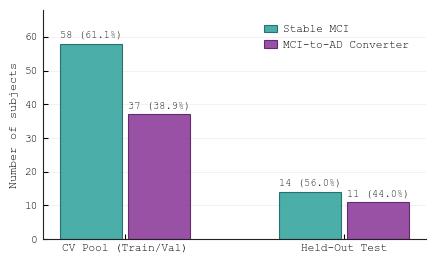

✓ fig0_cohort_design_and_distribution saved.


In [2]:
fig, ax = plt.subplots(figsize=(108 * MM, 64 * MM))

partitions = ['CV Pool (Train/Val)', 'Held-Out Test']
x = np.arange(len(partitions))
width = 0.28

stable_mci = [58, 14]
converters = [37, 11]
totals = [95, 25]

rects1 = ax.bar(
    x - width/2 - 0.015, stable_mci, width,
    label='Stable MCI',
    color=TEAL_FILL, edgecolor=TEAL_EDGE, linewidth=0.8, alpha=0.85
)
rects2 = ax.bar(
    x + width/2 + 0.015, converters, width,
    label='MCI-to-AD Converter',
    color=PURPLE_FILL, edgecolor=PURPLE_EDGE, linewidth=0.8, alpha=0.85
)

for i, rect in enumerate(rects1):
    h = rect.get_height()
    pct = h / totals[i] * 100
    ax.annotate(f'{int(h)} ({pct:.1f}%)',
                xy=(rect.get_x() + rect.get_width() / 2, h + 1.2),
                ha='center', va='bottom', color='#222222', fontsize=7.5)

for i, rect in enumerate(rects2):
    h = rect.get_height()
    pct = h / totals[i] * 100
    ax.annotate(f'{int(h)} ({pct:.1f}%)',
                xy=(rect.get_x() + rect.get_width() / 2, h + 1.2),
                ha='center', va='bottom', color='#222222', fontsize=7.5)

ax.set_ylabel('Number of subjects')
ax.set_xticks(x)
ax.set_xticklabels(partitions)
ax.set_ylim(0, 68)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_color('#222222')
ax.spines['bottom'].set_color('#222222')

ax.grid(axis='y', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
ax.set_axisbelow(True)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98),
    frameon=False,
    handlelength=1.2,
    handletextpad=0.5
)

fig.tight_layout(pad=0.4)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig0_cohort_design_and_distribution.pdf')
    fig.savefig(out_dir / 'fig0_cohort_design_and_distribution.png', dpi=600)

plt.show()
print('✓ fig0_cohort_design_and_distribution saved.')


## 2. Pooled ADNI + DELCODE Cohort Partition & Distribution (≥ 2 Visits)

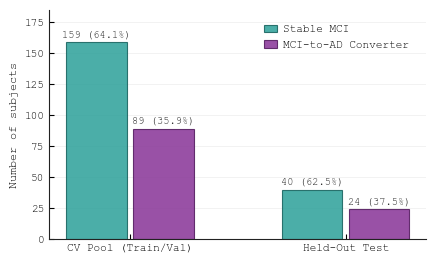

✓ fig_pooled_adni_delcode_distribution saved.


In [3]:
fig, ax = plt.subplots(figsize=(108 * MM, 64 * MM))

partitions = ['CV Pool (Train/Val)', 'Held-Out Test']
x = np.arange(len(partitions))
width = 0.28

# ADNI: 153 CV (101 stable, 52 conv), 39 Test (26 stable, 13 conv)
# DELCODE (>=2v): 95 CV (58 stable, 37 conv), 25 Test (14 stable, 11 conv)
# Combined: 248 CV (159 stable, 89 conv), 64 Test (40 stable, 24 conv)
stable = [159, 40]
converters = [89, 24]
totals = [248, 64]

rects1 = ax.bar(
    x - width/2 - 0.015, stable, width,
    label='Stable MCI',
    color=TEAL_FILL, edgecolor=TEAL_EDGE, linewidth=0.8, alpha=0.85
)
rects2 = ax.bar(
    x + width/2 + 0.015, converters, width,
    label='MCI-to-AD Converter',
    color=PURPLE_FILL, edgecolor=PURPLE_EDGE, linewidth=0.8, alpha=0.85
)

for i, rect in enumerate(rects1):
    h = rect.get_height()
    pct = h / totals[i] * 100
    ax.annotate(f'{int(h)} ({pct:.1f}%)',
                xy=(rect.get_x() + rect.get_width() / 2, h + 2.5),
                ha='center', va='bottom', color='#222222', fontsize=7.5)

for i, rect in enumerate(rects2):
    h = rect.get_height()
    pct = h / totals[i] * 100
    ax.annotate(f'{int(h)} ({pct:.1f}%)',
                xy=(rect.get_x() + rect.get_width() / 2, h + 2.5),
                ha='center', va='bottom', color='#222222', fontsize=7.5)

ax.set_ylabel('Number of subjects')
ax.set_xticks(x)
ax.set_xticklabels(partitions)
ax.set_ylim(0, 185)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_color('#222222')
ax.spines['bottom'].set_color('#222222')
ax.grid(axis='y', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
ax.set_axisbelow(True)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98),
    frameon=False,
    handlelength=1.2,
    handletextpad=0.5
)
fig.tight_layout(pad=0.4)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig_pooled_adni_delcode_distribution.pdf')
    fig.savefig(out_dir / 'fig_pooled_adni_delcode_distribution.png', dpi=600)

plt.show()
print('✓ fig_pooled_adni_delcode_distribution saved.')


## 3. Held-Out Test Sets Comparison: Pooled In-Domain vs. OASIS-3 External

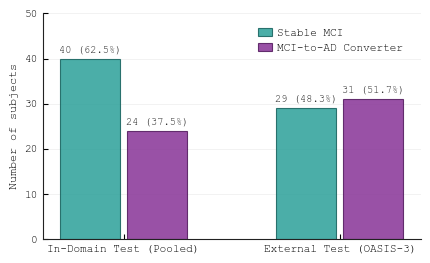

✓ fig_heldout_pooled_vs_oasis3 saved.


In [4]:
fig, ax = plt.subplots(figsize=(108 * MM, 64 * MM))

partitions = ['In-Domain Test (Pooled)', 'External Test (OASIS-3)']
x = np.arange(len(partitions))
width = 0.28

# Pooled In-Domain Test: 40 stable (62.5%), 24 converters (37.5%) -> Total 64
# OASIS-3 External Test: 29 stable (48.3%), 31 converters (51.7%) -> Total 60
stable = [40, 29]
converters = [24, 31]
totals = [64, 60]

rects1 = ax.bar(
    x - width/2 - 0.015, stable, width,
    label='Stable MCI',
    color=TEAL_FILL, edgecolor=TEAL_EDGE, linewidth=0.8, alpha=0.85
)
rects2 = ax.bar(
    x + width/2 + 0.015, converters, width,
    label='MCI-to-AD Converter',
    color=PURPLE_FILL, edgecolor=PURPLE_EDGE, linewidth=0.8, alpha=0.85
)

for i, rect in enumerate(rects1):
    h = rect.get_height()
    pct = h / totals[i] * 100
    ax.annotate(f'{int(h)} ({pct:.1f}%)',
                xy=(rect.get_x() + rect.get_width() / 2, h + 1.0),
                ha='center', va='bottom', color='#222222', fontsize=7.5)

for i, rect in enumerate(rects2):
    h = rect.get_height()
    pct = h / totals[i] * 100
    ax.annotate(f'{int(h)} ({pct:.1f}%)',
                xy=(rect.get_x() + rect.get_width() / 2, h + 1.0),
                ha='center', va='bottom', color='#222222', fontsize=7.5)

ax.set_ylabel('Number of subjects')
ax.set_xticks(x)
ax.set_xticklabels(partitions)
ax.set_ylim(0, 50)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_color('#222222')
ax.spines['bottom'].set_color('#222222')
ax.grid(axis='y', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
ax.set_axisbelow(True)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98),
    frameon=False,
    handlelength=1.2,
    handletextpad=0.5
)
fig.tight_layout(pad=0.4)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig_heldout_pooled_vs_oasis3.pdf')
    fig.savefig(out_dir / 'fig_heldout_pooled_vs_oasis3.png', dpi=600)

plt.show()
print('✓ fig_heldout_pooled_vs_oasis3 saved.')
